In [1]:
from __future__ import print_function
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import coremltools
from scipy import stats
from IPython.display import display, HTML

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn import preprocessing

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Reshape
from keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

scikit-learn version 1.7.0 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
I0000 00:00:1776948244.541859    7751 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776948245.003187    7751 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776948246.053555    7751 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_O

In [2]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

W0000 00:00:1776948249.569602    7751 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776948249.667484    7751 gpu_device.cc:2043] Created device /device:GPU:0 with 13236 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 2022890244505470025
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 13879738368
locality {
  bus_id: 1
  links {
  }
}
incarnation: 2589655293296061333
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a"
xla_global_id: 416903419
]


In [3]:
  import os
  os.chdir('/home/g00n3r/projects/esp32_cl_har')

  column_names = ['user-id', 'activity', 'timestamp', 'x-axis', 'y-axis', 'z-axis']
  df = pd.read_csv("data/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt",
                   header=None,
                   names=column_names,
                   on_bad_lines='skip')
  df['z-axis'] = df['z-axis'].replace(regex=True, to_replace=r';', value=r'')
  df['z-axis'] = df['z-axis'].apply(lambda x: float(str(x).replace(',', '.')))
  df.dropna(axis=0, how='any', inplace=True)
  df.head(20)

,user-id,activity,timestamp,x-axis,y-axis,z-axis
0,33,Jogging,49105962326000,-0.694638,12.680544,0.503953
1,33,Jogging,49106062271000,5.012288,11.264028,0.953424
2,33,Jogging,49106112167000,4.903325,10.882658,-0.081722
3,33,Jogging,49106222305000,-0.612916,18.496431,3.023717
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164
5,33,Jogging,49106442306000,1.375655,-2.492524,-6.510526
6,33,Jogging,49106542312000,-0.612916,10.569390,5.706926
7,33,Jogging,49106652389000,-0.503953,13.947236,7.055340
8,33,Jogging,49106762313000,-8.430995,11.413852,5.134871
9,33,Jogging,49106872299000,0.953424,1.375655,1.648062


In [4]:
print('Number of columns in the dataframe: %i' % (df.shape[1]))
print('Number of rows in the dataframe: %i\n' % (df.shape[0]))

Number of columns in the dataframe: 6
Number of rows in the dataframe: 1086465



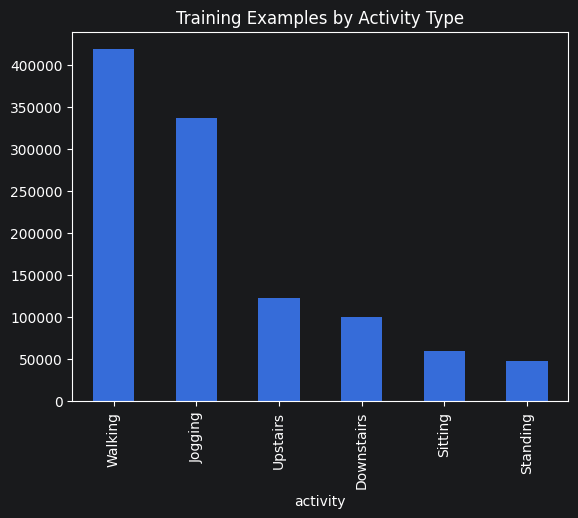

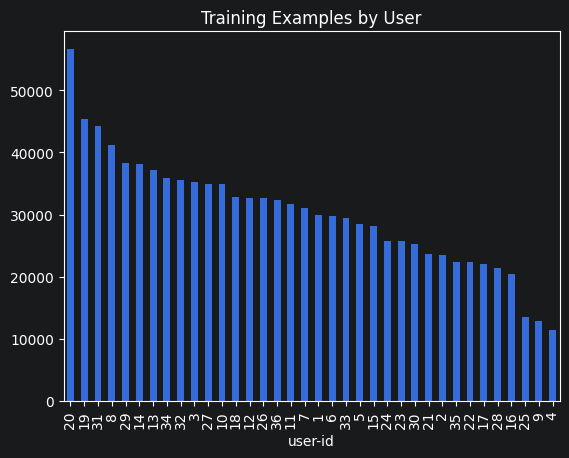

In [5]:
# Show how many training examples exist for each of the six activities
df['activity'].value_counts().plot(kind='bar',
                                   title='Training Examples by Activity Type')
plt.show()
# Better understand how the recordings are spread across the different
# users who participated in the study
df['user-id'].value_counts().plot(kind='bar',
                                  title='Training Examples by User')
plt.show()

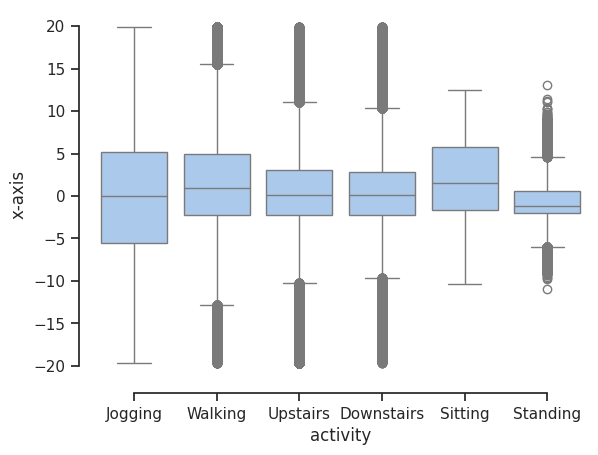

In [6]:
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")

# Draw a nested boxplot to show bills by day and time
sns.boxplot(data=df, x="activity", y="x-axis")
sns.despine(offset=10, trim=True)

## Розподіл прискорення по осі X для кожного типу активності

Boxplot відображає розподіл значень акселерометра (вісь X) по 6 класах активності з датасету WISDM.

- **Медіана** — горизонтальна лінія всередині box
- **IQR (25–75%)** — висота box
- **Вуса** — розкид без викидів

> Jogging і Upstairs мають найбільший розкид — характерно для динамічних рухів. Walking, Downstairs, Standing, Sitting — більш стабільні.


In [7]:
standing = df[df['activity'] == 'Standing']

Q1 = standing['x-axis'].quantile(0.25)
Q3 = standing['x-axis'].quantile(0.75)
IQR = Q3 - Q1

outliers = standing[
  (standing['x-axis'] < Q1 - 1.5 * IQR) |
  (standing['x-axis'] > Q3 + 1.5 * IQR)
]

print(f"Кількість викидів: {len(outliers)}")
print(outliers[['user-id', 'activity', 'x-axis']].describe())
outliers

Кількість викидів: 6095
           user-id       x-axis
count  6095.000000  6095.000000
mean     13.880886    -3.677358
std      10.377211     6.429887
min       5.000000   -10.990000
25%       7.000000    -7.930000
50%       8.000000    -7.350000
75%      31.000000     5.600000
max      31.000000    13.100000


,user-id,activity,timestamp,x-axis,y-axis,z-axis
223560,27,Standing,12542372296000,5.52,10.65,-2.451662
223561,27,Standing,12542422315000,-6.51,10.12,0.231546
400183,5,Standing,3210412273000,-6.66,6.32,-1.225831
542602,13,Standing,858492259000,-6.13,7.97,0.610000
542611,13,Standing,858942363000,-6.66,8.39,0.190000
...,...,...,...,...,...,...
1083695,19,Standing,131466241640000,-6.02,7.82,-0.500000
1083696,19,Standing,131466281496000,-6.09,7.78,-0.530000
1083724,19,Standing,131467691438000,-6.21,7.63,-0.530000
1083757,19,Standing,131469332857000,-6.09,8.47,0.080000
